# Batched ODE Solver Benchmark — CPU (Python threading) vs JAX/GPU

Compares six solver configurations across batch sizes:

| # | Solver | Backend | Step control |
|---|--------|---------|--------------|
| 1 | Explicit RK45   | JAX/GPU | Variable (adaptive) |
| 2 | Implicit BDF1   | JAX/GPU | Fixed |
| 3 | Implicit BDF2   | JAX/GPU | Variable (adaptive) |
| 4 | Explicit RK45   | CPU threads | Variable (adaptive) |
| 5 | Implicit BDF1   | CPU threads | Fixed |
| 6 | Implicit BDF2   | CPU threads | Variable (adaptive) |

**Test problem** (all solvers): stiff decoupled linear  
&emsp;y' = −λ(y − cos t) − sin t,&emsp;λᵢ ∈ [5, 60]  
Exact solution: y(t) = (y₀ − 1)exp(−λt) + cos(t)

**Note on RHS naming**: each solver section defines its own `rhs_*` function  
to avoid Python name shadowing across notebook cells.

In [ ]:
# %pip -q install -U "jax[cuda12_pip]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 MB 10.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.2 MB/s eta 0:00:00:00:01


In [ ]:
import os
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
# float64: required for newton_tol=1e-10 and rtol=1e-6 to be meaningful.
jax.config.update("jax_enable_x64", True)

print('JAX version   :', jax.__version__)
print('Devices       :', jax.devices())
print('Default backend:', jax.default_backend())
print('NumPy version :', np.__version__)
print('CPU cores     :', os.cpu_count())

JAX version   : 0.9.2
Devices       : [CpuDevice(id=0)]
Default backend: cpu
NumPy version : 2.0.2
CPU cores     : 2


In [12]:
# ===========================================================================
# Shared test problem
# ===========================================================================
# y' = -lam*(y - cos(t)) - sin(t),  exact: y(t) = (y0-1)*exp(-lam*t) + cos(t)
# Used by ALL solvers below — no function redefinition allowed in later cells.

def exact_solution(t, y0, lam):
    """Exact solution for correctness checks."""
    return (y0 - 1.0) * np.exp(-lam * t) + np.cos(t)


# ===========================================================================
# JAX/GPU Solver 1: Explicit variable-step RK45
# (uses rhs_exp to avoid shadowing rhs_imp defined in the next cell)
# ===========================================================================

def rhs_exp(t, y, lam):
    """Same stiff test problem as implicit solvers for apples-to-apples timing."""
    return -lam * (y - jnp.cos(t)) - jnp.sin(t)


def _rk45_step_single(t, y, h, lam):
    """Dormand-Prince 5(4) tableau."""
    k1 = rhs_exp(t,          y,                                                 lam)
    k2 = rhs_exp(t+h/5,      y+h*(1/5*k1),                                      lam)
    k3 = rhs_exp(t+3*h/10,   y+h*(3/40*k1+9/40*k2),                             lam)
    k4 = rhs_exp(t+4*h/5,    y+h*(44/45*k1-56/15*k2+32/9*k3),                   lam)
    k5 = rhs_exp(t+8*h/9,    y+h*(19372/6561*k1-25360/2187*k2
                                  +64448/6561*k3-212/729*k4),                    lam)
    k6 = rhs_exp(t+h,        y+h*(9017/3168*k1-355/33*k2+46732/5247*k3
                                  +49/176*k4-5103/18656*k5),                     lam)
    y5 = y+h*(35/384*k1+500/1113*k3+125/192*k4-2187/6784*k5+11/84*k6)
    k7 = rhs_exp(t+h, y5, lam)
    y4 = y+h*(5179/57600*k1+7571/16695*k3+393/640*k4
              -92097/339200*k5+187/2100*k6+1/40*k7)
    return y5, y5-y4


def _err_norm(y_old, y_new, err, rtol, atol):
    sc = atol + rtol * jnp.maximum(jnp.abs(y_old), jnp.abs(y_new))
    return jnp.sqrt(jnp.mean((err/sc)**2, axis=1))


def solve_explicit_variable_batch_jax(
    y0_batch, lam_batch, t_span=(0.,6.), rtol=1e-6, atol=1e-8,
    h_init=1e-3, h_min=1e-7, h_max=0.2, max_iters=200_000,
    safety=0.9, min_factor=0.2, max_factor=5.0,
):
    t0, tf = float(t_span[0]), float(t_span[1])
    y   = jnp.array(y0_batch, dtype=jnp.float64)
    lam = jnp.array(lam_batch, dtype=jnp.float64)
    B   = y.shape[0]
    t   = jnp.full((B,), t0)
    h   = jnp.full((B,), h_init)
    done = jnp.zeros((B,), dtype=bool)
    n_acc = jnp.zeros((B,), jnp.int32)
    n_rej = jnp.zeros((B,), jnp.int32)

    for _ in range(max_iters):
        active = ~done
        if not bool(jnp.any(active)):
            break
        h_eff = jnp.clip(jnp.where(active, jnp.minimum(h, tf-t), h), h_min, h_max)
        y_c, ev = jax.vmap(_rk45_step_single)(t, y, h_eff, lam)
        err = _err_norm(y, y_c, ev, rtol, atol)
        acc = (err <= 1.) & active
        t = jnp.where(acc, t+h_eff, t)
        y = jnp.where(acc[:,None], y_c, y)
        se = jnp.where(err>0, err, 1e-300)
        fa = jnp.where(err==0., max_factor, jnp.clip(safety*se**(-0.2), min_factor, max_factor))
        fr = jnp.clip(safety*se**(-0.2), min_factor, 1.)
        h  = jnp.where(active, jnp.clip(jnp.where(acc, h_eff*fa, h_eff*fr), h_min, h_max), h)
        done = done | (t >= tf-1e-12)
        n_acc += acc.astype(jnp.int32)
        n_rej += (~acc & active).astype(jnp.int32)

    return dict(y_final=np.array(y), n_accept=np.array(n_acc), n_reject=np.array(n_rej))


# ===========================================================================
# JAX/GPU Solver 2: Implicit fixed-step BDF1
# ===========================================================================

def rhs_imp(t, y, lam):
    return -lam * (y - jnp.cos(t)) - jnp.sin(t)


def jac_imp(t, y, lam):
    return -jnp.diag(lam)


def _newton_be(y_prev, t_next, h, lam, tol=1e-10, max_iter=20):
    B, d = y_prev.shape
    eye  = jnp.eye(d)
    y    = y_prev.copy()
    conv = jnp.zeros((B,), dtype=bool)
    iters = jnp.zeros((B,), jnp.int32)
    for k in range(max_iter):
        f    = jax.vmap(rhs_imp)(t_next, y, lam)
        res  = y - y_prev - h[:,None]*f
        rn   = jnp.max(jnp.abs(res), axis=1)
        jc   = (~conv) & (rn < tol)
        iters = jnp.where(jc, k+1, iters)
        conv  = conv | jc
        if bool(jnp.all(conv)): break
        Jf  = jax.vmap(jac_imp)(t_next, y, lam)
        A   = eye[None] - h[:,None,None]*Jf
        d_y = jnp.linalg.solve(A, -res[...,None]).squeeze(-1)
        d_y = jnp.where(conv[:,None], 0., d_y)
        y   = y + d_y
        dn  = jnp.max(jnp.abs(d_y), axis=1)
        jc2 = (~conv) & (dn < tol)
        iters = jnp.where(jc2, k+2, iters)
        conv  = conv | jc2
    iters = jnp.where((iters==0)&conv, 1, iters)
    iters = jnp.where(~conv, max_iter, iters)
    return y, conv, iters


def solve_implicit_fixed_batch_jax(
    y0_batch, lam_batch, t_span=(0.,6.), dt=0.02,
    newton_tol=1e-10, newton_max_iter=20,
):
    t0, tf = float(t_span[0]), float(t_span[1])
    y   = jnp.array(y0_batch, dtype=jnp.float64)
    lam = jnp.array(lam_batch, dtype=jnp.float64)
    B   = y.shape[0]
    t   = jnp.full((B,), t0)
    suc = jnp.ones((B,), dtype=bool)
    nit = jnp.zeros((B,), jnp.int32)
    n_steps = int(np.ceil((tf-t0)/dt))
    for _ in range(n_steps):
        h  = jnp.minimum(jnp.full((B,), dt), tf-t)
        tn = t + h
        yn, cv, ni = _newton_be(y, tn, h, lam, tol=newton_tol, max_iter=newton_max_iter)
        y   = jnp.where(cv[:,None], yn, y)
        t   = jnp.where(cv, tn, t)
        suc = suc & cv
        nit = nit + ni
    return dict(y_final=np.array(y), success=np.array(suc), n_newton_total=np.array(nit))


# ===========================================================================
# JAX/GPU Solver 3: Implicit variable-step BDF2
# ===========================================================================

def _newton_bdf2(y_nm1, y_n, t_next, h_prev, h, lam, tol=1e-10, max_iter=20):
    B, d = y_n.shape
    eye  = jnp.eye(d)
    r    = h/h_prev
    a0   = (1.+2.*r)/(h*(1.+r));  a1 = -(1.+r)/h;  a2 = r*r/(h*(1.+r))
    y    = y_n + (h/h_prev)[:,None]*(y_n - y_nm1)
    conv  = jnp.zeros((B,), dtype=bool)
    iters = jnp.zeros((B,), jnp.int32)
    for k in range(max_iter):
        f    = jax.vmap(rhs_imp)(t_next, y, lam)
        res  = a0[:,None]*y + a1[:,None]*y_n + a2[:,None]*y_nm1 - f
        rn   = jnp.max(jnp.abs(res), axis=1)
        jc   = (~conv) & (rn < tol)
        iters = jnp.where(jc, k+1, iters)
        conv  = conv | jc
        if bool(jnp.all(conv)): break
        Jf  = jax.vmap(jac_imp)(t_next, y, lam)
        A   = a0[:,None,None]*eye[None] - Jf
        d_y = jnp.linalg.solve(A, -res[...,None]).squeeze(-1)
        d_y = jnp.where(conv[:,None], 0., d_y)
        y   = y + d_y
        dn  = jnp.max(jnp.abs(d_y), axis=1)
        jc2 = (~conv) & (dn < tol)
        iters = jnp.where(jc2, k+2, iters)
        conv  = conv | jc2
    iters = jnp.where((iters==0)&conv, 1, iters)
    iters = jnp.where(~conv, max_iter, iters)
    return y, conv, iters


def _err_norm_iv(yo, yn, err, rtol, atol):
    sc = atol + rtol*jnp.maximum(jnp.abs(yo), jnp.abs(yn))
    return jnp.sqrt(jnp.mean((err/sc)**2, axis=1))


def solve_implicit_variable_batch_jax(
    y0_batch, lam_batch, t_span=(0.,6.), rtol=1e-6, atol=1e-8,
    h_init=1e-3, h_min=1e-7, h_max=0.2, max_iters=200_000,
    newton_tol=1e-10, newton_max_iter=20,
    safety=0.9, min_factor=0.2, max_factor=3.0,
):
    t0, tf = float(t_span[0]), float(t_span[1])
    yn   = jnp.array(y0_batch, dtype=jnp.float64)
    lam  = jnp.array(lam_batch, dtype=jnp.float64)
    B    = yn.shape[0]
    t    = jnp.full((B,), t0)
    h    = jnp.full((B,), h_init)
    hp   = jnp.full((B,), h_init)
    ynm1 = yn
    has_p = jnp.zeros((B,), dtype=bool)
    done  = jnp.zeros((B,), dtype=bool)
    n_acc = jnp.zeros((B,), jnp.int32)
    n_rej = jnp.zeros((B,), jnp.int32)
    n_nit = jnp.zeros((B,), jnp.int32)

    for _ in range(max_iters):
        active = ~done
        if not bool(jnp.any(active)): break
        he = jnp.clip(jnp.where(active, jnp.minimum(h, tf-t), h), h_min, h_max)
        tn = t + he

        y_be, ok_be, nbe = _newton_be(yn, tn, he, lam, tol=newton_tol, max_iter=newton_max_iter)
        n_nit = n_nit + nbe
        hp_s  = jnp.where(hp>0, hp, h_init)
        y_b2, ok_b2, nb2 = _newton_bdf2(ynm1, yn, tn, hp_s, he, lam,
                                         tol=newton_tol, max_iter=newton_max_iter)
        n_nit = n_nit + jnp.where(has_p, nb2, 0)

        err_b2 = _err_norm_iv(yn, y_b2, y_b2-y_be, rtol, atol)
        err    = jnp.where(has_p, err_b2, 0.)
        ca     = ok_be & (~has_p | ok_b2)
        acc    = active & ca & (err <= 1.)

        yh      = jnp.where(has_p[:,None], y_b2, y_be)
        ynm1_n  = jnp.where(acc[:,None], yn,  ynm1)
        yn_n    = jnp.where(acc[:,None], yh,  yn)
        t_n     = jnp.where(acc, tn, t)
        hp_n    = jnp.where(acc, he, hp)
        hasp_n  = has_p | acc

        p   = jnp.where(has_p, 2., 1.)
        se  = jnp.where(err>0, err, 1e-300)
        fa  = jnp.where(err==0., max_factor, jnp.clip(safety*se**(-1./(p+1.)), min_factor, max_factor))
        fr  = jnp.where(has_p, jnp.clip(safety*se**(-1./(p+1.)), min_factor, 1.), 0.5)
        h_n = jnp.where(active, jnp.clip(jnp.where(acc, he*fa, he*fr), h_min, h_max), h)
        done_n = done | (t_n >= tf-1e-12)

        n_acc += acc.astype(jnp.int32)
        n_rej += (~acc & active).astype(jnp.int32)
        ynm1, yn, t, hp, has_p, h, done = ynm1_n, yn_n, t_n, hp_n, hasp_n, h_n, done_n

    return dict(y_final=np.array(yn), n_accept=np.array(n_acc),
                n_reject=np.array(n_rej), n_newton_total=np.array(n_nit))

In [13]:
# ===========================================================================
# CPU Solver 4: Explicit variable-step RK45 (NumPy + ThreadPoolExecutor)
# ===========================================================================

def _rk45_step_np(t, y, h, lam):
    """Dormand-Prince 5(4), NumPy, same stiff RHS."""
    def f(tt, yy): return -lam*(yy - np.cos(tt)) - np.sin(tt)
    k1 = f(t,          y)
    k2 = f(t+h/5,      y+h*(1/5*k1))
    k3 = f(t+3*h/10,   y+h*(3/40*k1+9/40*k2))
    k4 = f(t+4*h/5,    y+h*(44/45*k1-56/15*k2+32/9*k3))
    k5 = f(t+8*h/9,    y+h*(19372/6561*k1-25360/2187*k2+64448/6561*k3-212/729*k4))
    k6 = f(t+h,        y+h*(9017/3168*k1-355/33*k2+46732/5247*k3+49/176*k4-5103/18656*k5))
    y5 = y+h*(35/384*k1+500/1113*k3+125/192*k4-2187/6784*k5+11/84*k6)
    k7 = f(t+h, y5)
    y4 = y+h*(5179/57600*k1+7571/16695*k3+393/640*k4-92097/339200*k5+187/2100*k6+1/40*k7)
    return y5, y5-y4


def _solve_explicit_cpu_one(args):
    y0, lam, t_span, rtol, atol, h_init, h_min, h_max = args
    t0, tf = t_span
    y = y0.copy(); t = t0; h = h_init
    n_acc = n_rej = 0
    max_steps = 200_000
    for _ in range(max_steps):
        h = min(h, tf-t)
        if h < h_min: break
        y5, ev = _rk45_step_np(t, y, h, lam)
        sc  = atol + rtol*np.maximum(np.abs(y), np.abs(y5))
        err = float(np.sqrt(np.mean((ev/sc)**2)))
        se  = max(err, 1e-300)
        if err <= 1.:
            t += h; y = y5; n_acc += 1
            h = min(h_max, max(h_min, h * min(5., max(0.2, 0.9*se**(-0.2)))))
        else:
            n_rej += 1
            h = max(h_min, h * min(1., max(0.2, 0.9*se**(-0.2))))
        if t >= tf-1e-12: break
    return y, n_acc, n_rej


def solve_explicit_cpu_batch(y0_batch, lam_batch, t_span, rtol=1e-6, atol=1e-8,
                             h_init=1e-3, h_min=1e-7, h_max=0.2, n_workers=None):
    if n_workers is None:
        n_workers = os.cpu_count()
    B = len(y0_batch)
    args = [(y0_batch[i], lam_batch[i], t_span, rtol, atol, h_init, h_min, h_max)
            for i in range(B)]
    results = [None]*B
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = {pool.submit(_solve_explicit_cpu_one, a): i for i, a in enumerate(args)}
        for fut in as_completed(futs):
            results[futs[fut]] = fut.result()
    y_final  = np.array([r[0] for r in results])
    n_accept = np.array([r[1] for r in results])
    n_reject = np.array([r[2] for r in results])
    return dict(y_final=y_final, n_accept=n_accept, n_reject=n_reject)


# ===========================================================================
# CPU Solver 5: Implicit fixed-step BDF1 (NumPy + ThreadPoolExecutor)
# ===========================================================================

def _solve_implicit_fixed_cpu_one(args):
    y0, lam, t_span, dt, newton_tol, newton_max_iter = args
    t0, tf = t_span
    y = y0.copy(); t = t0
    n = y.size; I = np.eye(n)
    Jf = -np.diag(lam)   # constant analytic Jacobian for this problem
    n_newton = 0
    n_steps  = int(np.ceil((tf-t0)/dt))
    success  = True
    for _ in range(n_steps):
        h  = min(dt, tf-t); tn = t+h
        yy = y.copy()
        A  = I - h*Jf
        for k in range(newton_max_iter):
            f   = -lam*(yy - np.cos(tn)) - np.sin(tn)
            res = yy - y - h*f
            if np.max(np.abs(res)) < newton_tol: break
            try: d = np.linalg.solve(A, -res)
            except np.linalg.LinAlgError: success=False; break
            yy += d
            n_newton += 1
            if np.max(np.abs(d)) < newton_tol: break
        else:
            n_newton += newton_max_iter
        if not success: break
        y = yy; t = tn
    return y, success, n_newton


def solve_implicit_fixed_cpu_batch(y0_batch, lam_batch, t_span, dt=0.02,
                                   newton_tol=1e-10, newton_max_iter=20,
                                   n_workers=None):
    if n_workers is None:
        n_workers = os.cpu_count()
    B = len(y0_batch)
    args = [(y0_batch[i], lam_batch[i], t_span, dt, newton_tol, newton_max_iter)
            for i in range(B)]
    results = [None]*B
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = {pool.submit(_solve_implicit_fixed_cpu_one, a): i for i, a in enumerate(args)}
        for fut in as_completed(futs):
            results[futs[fut]] = fut.result()
    y_final  = np.array([r[0] for r in results])
    success  = np.array([r[1] for r in results])
    n_newton = np.array([r[2] for r in results])
    return dict(y_final=y_final, success=success, n_newton_total=n_newton)


# ===========================================================================
# CPU Solver 6: Implicit variable-step BDF2 (NumPy + ThreadPoolExecutor)
# ===========================================================================

def _solve_implicit_variable_cpu_one(args):
    y0, lam, t_span, rtol, atol, h_init, h_min, h_max, newton_tol, newton_max_iter = args
    t0, tf = t_span
    n = y0.size; I = np.eye(n)
    y_n = y0.copy(); y_nm1 = None; t = t0
    h = h_init; h_prev = None
    n_acc = n_rej = n_newton = 0
    max_steps = 200_000

    def _f(tt, yy): return -lam*(yy - np.cos(tt)) - np.sin(tt)
    def _Jf(_t, _y): return -np.diag(lam)

    for _ in range(max_steps):
        h = min(h, tf-t)
        if h < h_min: break
        tn = t+h

        # BE
        yy = y_n.copy()
        Jf = _Jf(tn, yy)
        A_be = I - h*Jf
        ok_be = False
        for k in range(newton_max_iter):
            res = yy - y_n - h*_f(tn, yy)
            if np.max(np.abs(res)) < newton_tol: ok_be=True; break
            try: d = np.linalg.solve(A_be, -res)
            except: break
            yy += d; n_newton += 1
            if np.max(np.abs(d)) < newton_tol: ok_be=True; break
        y_be = yy

        if not ok_be:
            n_rej += 1; h = max(h_min, h*0.5); continue

        if y_nm1 is None or h_prev is None:
            err = 0.; y_high = y_be; p = 1
        else:
            r  = h/h_prev
            a0 = (1.+2.*r)/(h*(1.+r)); a1 = -(1.+r)/h; a2 = r*r/(h*(1.+r))
            yy2 = y_n + (h/h_prev)*(y_n - y_nm1)
            ok_b2 = False
            for k in range(newton_max_iter):
                f2  = _f(tn, yy2)
                res2 = a0*yy2 + a1*y_n + a2*y_nm1 - f2
                if np.max(np.abs(res2)) < newton_tol: ok_b2=True; break
                Jf2 = _Jf(tn, yy2)
                A2  = a0*I - Jf2
                try: d2 = np.linalg.solve(A2, -res2)
                except: break
                yy2 += d2; n_newton += 1
                if np.max(np.abs(d2)) < newton_tol: ok_b2=True; break
            if not ok_b2:
                n_rej += 1; h = max(h_min, h*0.5); continue
            y_high = yy2
            sc  = atol + rtol*np.maximum(np.abs(y_n), np.abs(y_high))
            err = float(np.sqrt(np.mean(((y_high-y_be)/sc)**2)))
            p   = 2

        if err <= 1.:
            y_nm1 = y_n.copy(); y_n = y_high; t = tn; h_prev = h; n_acc += 1
            se = max(err, 1e-300)
            fac = 0.9 * se**(-1./(p+1.))
            h = float(np.clip(h * min(3., max(0.2, fac)), h_min, h_max))
        else:
            n_rej += 1
            se  = max(err, 1e-300)
            fac = 0.9 * se**(-1./(p+1.))
            h   = float(max(h_min, h * min(1., max(0.2, fac))))
        if t >= tf-1e-12: break

    return y_n, n_acc, n_rej, n_newton


def solve_implicit_variable_cpu_batch(y0_batch, lam_batch, t_span,
                                      rtol=1e-6, atol=1e-8,
                                      h_init=1e-3, h_min=1e-7, h_max=0.2,
                                      newton_tol=1e-10, newton_max_iter=20,
                                      n_workers=None):
    if n_workers is None:
        n_workers = os.cpu_count()
    B = len(y0_batch)
    args = [(y0_batch[i], lam_batch[i], t_span, rtol, atol,
             h_init, h_min, h_max, newton_tol, newton_max_iter)
            for i in range(B)]
    results = [None]*B
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        futs = {pool.submit(_solve_implicit_variable_cpu_one, a): i for i, a in enumerate(args)}
        for fut in as_completed(futs):
            results[futs[fut]] = fut.result()
    y_final  = np.array([r[0] for r in results])
    n_accept = np.array([r[1] for r in results])
    n_reject = np.array([r[2] for r in results])
    n_newton = np.array([r[3] for r in results])
    return dict(y_final=y_final, n_accept=n_accept, n_reject=n_reject, n_newton_total=n_newton)

In [14]:
# ===========================================================================
# JAX Warmup — run tiny batches once to trigger XLA compilation
# ===========================================================================
print("JAX warmup (triggers XLA compilation, not timed)...")
_w0 = np.zeros((4,4)); _w1 = np.ones((4,4)) * 5.
_ = solve_explicit_variable_batch_jax(_w0, _w1, t_span=(0.,0.01), max_iters=5)
_ = solve_implicit_fixed_batch_jax(_w0, _w1, t_span=(0.,0.02), dt=0.02)
_ = solve_implicit_variable_batch_jax(_w0, _w1, t_span=(0.,0.01), max_iters=5)
print("Warmup complete.")

JAX warmup (triggers XLA compilation, not timed)...
Warmup complete.


In [15]:
# ===========================================================================
# Main benchmark sweep
# ===========================================================================
BATCH_SIZES = [64, 128, 256, 512]
DIM         = 4
T_SPAN      = (0., 6.)
TF          = T_SPAN[1]

SOLVER_CFG = dict(
    # shared
    t_span=T_SPAN, rtol=1e-6, atol=1e-8,
    h_init=1e-3, h_min=1e-7, h_max=0.2,
    # implicit fixed
    dt=0.02,
    # implicit newton
    newton_tol=1e-10, newton_max_iter=20,
)

records = []

for bs in BATCH_SIZES:
    rng = np.random.default_rng(1000 + bs)
    y0  = rng.normal(size=(bs, DIM))
    lam = rng.uniform(5., 60., size=(bs, DIM))
    rec = {'batch_size': bs}

    # ---- JAX solvers ----
    t0 = time.perf_counter()
    oj = solve_explicit_variable_batch_jax(y0, lam, **{k:v for k,v in SOLVER_CFG.items()
                                                       if k in ('t_span','rtol','atol','h_init','h_min','h_max')})
    rec['jax_exp_s']       = time.perf_counter()-t0
    rec['jax_exp_acc']     = float(oj['n_accept'].mean())
    rec['jax_exp_err']     = float(np.max([np.max(np.abs(oj['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    t0 = time.perf_counter()
    oi = solve_implicit_fixed_batch_jax(y0, lam, t_span=T_SPAN, dt=SOLVER_CFG['dt'],
                                        newton_tol=SOLVER_CFG['newton_tol'],
                                        newton_max_iter=SOLVER_CFG['newton_max_iter'])
    rec['jax_if_s']        = time.perf_counter()-t0
    rec['jax_if_success']  = float(oi['success'].mean())
    rec['jax_if_err']      = float(np.max([np.max(np.abs(oi['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    t0 = time.perf_counter()
    ov = solve_implicit_variable_batch_jax(y0, lam, **{k:v for k,v in SOLVER_CFG.items()
                                                       if k in ('t_span','rtol','atol','h_init','h_min','h_max',
                                                                'newton_tol','newton_max_iter')})
    rec['jax_iv_s']        = time.perf_counter()-t0
    rec['jax_iv_acc']      = float(ov['n_accept'].mean())
    rec['jax_iv_err']      = float(np.max([np.max(np.abs(ov['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    # ---- CPU solvers ----
    t0 = time.perf_counter()
    ce = solve_explicit_cpu_batch(y0, lam, T_SPAN, rtol=SOLVER_CFG['rtol'], atol=SOLVER_CFG['atol'],
                                   h_init=SOLVER_CFG['h_init'], h_min=SOLVER_CFG['h_min'],
                                   h_max=SOLVER_CFG['h_max'])
    rec['cpu_exp_s']       = time.perf_counter()-t0
    rec['cpu_exp_acc']     = float(ce['n_accept'].mean())
    rec['cpu_exp_err']     = float(np.max([np.max(np.abs(ce['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    t0 = time.perf_counter()
    ci = solve_implicit_fixed_cpu_batch(y0, lam, T_SPAN, dt=SOLVER_CFG['dt'],
                                        newton_tol=SOLVER_CFG['newton_tol'],
                                        newton_max_iter=SOLVER_CFG['newton_max_iter'])
    rec['cpu_if_s']        = time.perf_counter()-t0
    rec['cpu_if_success']  = float(ci['success'].mean())
    rec['cpu_if_err']      = float(np.max([np.max(np.abs(ci['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    t0 = time.perf_counter()
    cv = solve_implicit_variable_cpu_batch(y0, lam, T_SPAN,
                                           rtol=SOLVER_CFG['rtol'], atol=SOLVER_CFG['atol'],
                                           h_init=SOLVER_CFG['h_init'], h_min=SOLVER_CFG['h_min'],
                                           h_max=SOLVER_CFG['h_max'],
                                           newton_tol=SOLVER_CFG['newton_tol'],
                                           newton_max_iter=SOLVER_CFG['newton_max_iter'])
    rec['cpu_iv_s']        = time.perf_counter()-t0
    rec['cpu_iv_acc']      = float(cv['n_accept'].mean())
    rec['cpu_iv_err']      = float(np.max([np.max(np.abs(cv['y_final'][i]-exact_solution(TF,y0[i],lam[i])))
                                           for i in range(bs)]))

    records.append(rec)
    print(f"batch={bs:4d} | "
          f"JAX exp={rec['jax_exp_s']:.2f}s if={rec['jax_if_s']:.2f}s iv={rec['jax_iv_s']:.2f}s | "
          f"CPU exp={rec['cpu_exp_s']:.2f}s if={rec['cpu_if_s']:.2f}s iv={rec['cpu_iv_s']:.2f}s")

batch=  64 | JAX exp=14.32s if=2.92s iv=230.54s | CPU exp=2.54s if=0.88s iv=86.25s
batch= 128 | JAX exp=15.65s if=3.05s iv=259.50s | CPU exp=3.89s if=1.76s iv=163.54s
batch= 256 | JAX exp=21.56s if=4.95s iv=292.08s | CPU exp=8.52s if=3.50s iv=330.78s
batch= 512 | JAX exp=22.44s if=4.87s iv=295.34s | CPU exp=15.84s if=6.93s iv=649.86s


In [16]:
# ===========================================================================
# Results summary table
# ===========================================================================
print(f"\n{'':=<110}")
print(f"{'Batch':>6}  "
      f"{'JAX-exp(s)':>11} {'JAX-if(s)':>10} {'JAX-iv(s)':>10}  "
      f"{'CPU-exp(s)':>11} {'CPU-if(s)':>10} {'CPU-iv(s)':>10}  "
      f"{'Speedup-exp':>12} {'Speedup-if':>11} {'Speedup-iv':>11}")
print(f"{'':=<110}")
for r in records:
    bs = r['batch_size']
    su_exp = r['cpu_exp_s'] / max(r['jax_exp_s'], 1e-9)
    su_if  = r['cpu_if_s']  / max(r['jax_if_s'],  1e-9)
    su_iv  = r['cpu_iv_s']  / max(r['jax_iv_s'],  1e-9)
    print(f"{bs:6d}  "
          f"{r['jax_exp_s']:11.3f} {r['jax_if_s']:10.3f} {r['jax_iv_s']:10.3f}  "
          f"{r['cpu_exp_s']:11.3f} {r['cpu_if_s']:10.3f} {r['cpu_iv_s']:10.3f}  "
          f"{su_exp:12.1f}x {su_if:10.1f}x {su_iv:10.1f}x")
print(f"{'':=<110}")

print("\nCorrectness — max |error| vs exact solution:")
print(f"{'Batch':>6}  {'JAX-exp':>10} {'JAX-if':>10} {'JAX-iv':>10}  "
      f"{'CPU-exp':>10} {'CPU-if':>10} {'CPU-iv':>10}")
for r in records:
    print(f"{r['batch_size']:6d}  "
          f"{r['jax_exp_err']:10.2e} {r['jax_if_err']:10.2e} {r['jax_iv_err']:10.2e}  "
          f"{r['cpu_exp_err']:10.2e} {r['cpu_if_err']:10.2e} {r['cpu_iv_err']:10.2e}")


 Batch   JAX-exp(s)  JAX-if(s)  JAX-iv(s)   CPU-exp(s)  CPU-if(s)  CPU-iv(s)   Speedup-exp  Speedup-if  Speedup-iv
    64       14.322      2.922    230.536        2.540      0.884     86.250           0.2x        0.3x        0.4x
   128       15.646      3.050    259.495        3.888      1.757    163.535           0.2x        0.6x        0.6x
   256       21.557      4.954    292.082        8.517      3.495    330.781           0.4x        0.7x        1.1x
   512       22.441      4.870    295.340       15.838      6.932    649.858           0.7x        1.4x        2.2x

Correctness — max |error| vs exact solution:
 Batch     JAX-exp     JAX-if     JAX-iv     CPU-exp     CPU-if     CPU-iv
    64    7.69e-07   1.61e-03   4.13e-08    7.69e-07   1.61e-03   4.13e-08
   128    7.56e-07   1.72e-03   4.62e-08    7.56e-07   1.72e-03   4.62e-08
   256    7.77e-07   1.73e-03   4.66e-08    7.77e-07   1.73e-03   4.66e-08
   512    7.69e-07   1.71e-03   4.56e-08    7.69e-07   1.71e-03   4.56e-08

/tmp/ipykernel_45817/3767317967.py:59: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.semilogy(bs_arr, err, '-o', label=lbl, color=col,


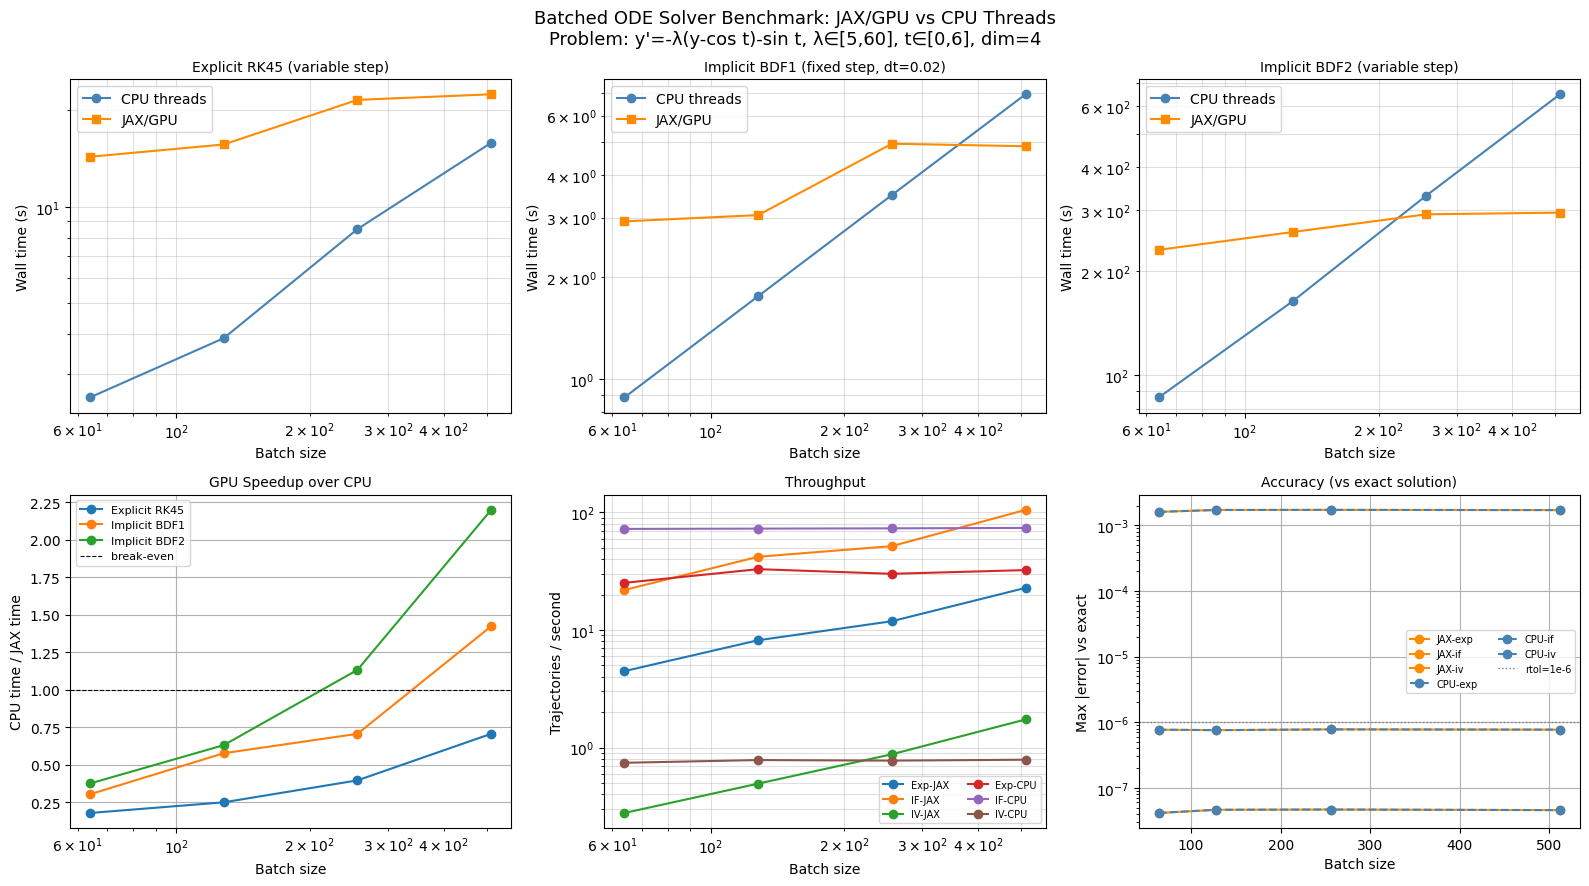

Saved benchmark_results.png


In [17]:
# ===========================================================================
# Plots
# ===========================================================================
bs_arr = np.array([r['batch_size'] for r in records])

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Batched ODE Solver Benchmark: JAX/GPU vs CPU Threads\n'
             'Problem: y\'=-λ(y-cos t)-sin t, λ∈[5,60], t∈[0,6], dim=4', fontsize=13)

# --- Row 0: Runtime vs batch size per solver type ---
for ax, (jkey, ckey, title) in zip(axes[0], [
    ('jax_exp_s', 'cpu_exp_s', 'Explicit RK45 (variable step)'),
    ('jax_if_s',  'cpu_if_s',  'Implicit BDF1 (fixed step, dt=0.02)'),
    ('jax_iv_s',  'cpu_iv_s',  'Implicit BDF2 (variable step)'),
]):
    jt = np.array([r[jkey] for r in records])
    ct = np.array([r[ckey] for r in records])
    ax.loglog(bs_arr, ct, '-o', label='CPU threads', color='steelblue')
    ax.loglog(bs_arr, jt, '-s', label='JAX/GPU',     color='darkorange')
    ax.set_xlabel('Batch size');  ax.set_ylabel('Wall time (s)')
    ax.set_title(title, fontsize=10); ax.legend(); ax.grid(True, which='both', alpha=0.4)

# --- Row 1: Speedup, throughput, and error ---
# Speedup
ax = axes[1][0]
for (jkey, ckey, label) in [
    ('jax_exp_s', 'cpu_exp_s', 'Explicit RK45'),
    ('jax_if_s',  'cpu_if_s',  'Implicit BDF1'),
    ('jax_iv_s',  'cpu_iv_s',  'Implicit BDF2'),
]:
    su = np.array([r[ckey]/max(r[jkey],1e-9) for r in records])
    ax.semilogx(bs_arr, su, '-o', label=label)
ax.axhline(1., ls='--', color='k', lw=0.8, label='break-even')
ax.set_xlabel('Batch size'); ax.set_ylabel('CPU time / JAX time')
ax.set_title('GPU Speedup over CPU', fontsize=10); ax.legend(fontsize=8); ax.grid(True)

# Throughput (trajectories/s)
ax = axes[1][1]
for (jkey, ckey, label) in [
    ('jax_exp_s', 'cpu_exp_s', 'Exp-JAX'),
    ('jax_if_s',  'cpu_if_s',  'IF-JAX'),
    ('jax_iv_s',  'cpu_iv_s',  'IV-JAX'),
    ('cpu_exp_s', 'cpu_exp_s', 'Exp-CPU'),
    ('cpu_if_s',  'cpu_if_s',  'IF-CPU'),
    ('cpu_iv_s',  'cpu_iv_s',  'IV-CPU'),
]:
    tp = bs_arr / np.array([r[jkey] for r in records])
    ax.loglog(bs_arr, tp, '-o', label=label)
ax.set_xlabel('Batch size'); ax.set_ylabel('Trajectories / second')
ax.set_title('Throughput', fontsize=10); ax.legend(fontsize=7, ncol=2); ax.grid(True, which='both', alpha=0.4)

# Max error vs exact at largest batch
ax = axes[1][2]
labels = ['JAX-exp', 'JAX-if', 'JAX-iv', 'CPU-exp', 'CPU-if', 'CPU-iv']
keys   = ['jax_exp_err','jax_if_err','jax_iv_err','cpu_exp_err','cpu_if_err','cpu_iv_err']
colors = ['darkorange']*3 + ['steelblue']*3
errs   = [np.array([r[k] for r in records]) for k in keys]
for i, (err, lbl, col) in enumerate(zip(errs, labels, colors)):
    ax.semilogy(bs_arr, err, '-o', label=lbl, color=col,
                linestyle='-' if 'JAX' in lbl else '--')
ax.axhline(1e-6, ls=':', color='gray', lw=1, label='rtol=1e-6')
ax.set_xlabel('Batch size'); ax.set_ylabel('Max |error| vs exact')
ax.set_title('Accuracy (vs exact solution)', fontsize=10)
ax.legend(fontsize=7, ncol=2); ax.grid(True)

plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved benchmark_results.png")